### Multi-class classification (Severity 1–4) using:
###  - Baseline: Logistic Regression
###  - Random Forest Classifier
###  - XGBoost Classifier

In [8]:
import argparse
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    f1_score,
    ConfusionMatrixDisplay,
)
from xgboost import XGBClassifier

warnings.filterwarnings("ignore")

In [2]:
# CONFIG

TARGET = "Severity"

NUMERIC_FEATURES = [
    "Temperature(F)",
    "Wind_Chill(F)",
    "Humidity(%)",
    "Pressure(in)",
    "Visibility(mi)",
    "Wind_Speed(mph)",
    "Precipitation(in)",
    "Distance(mi)",
]

BOOLEAN_FEATURES = [
    "Amenity", "Bump", "Crossing", "Give_Way", "Junction",
    "No_Exit", "Railway", "Roundabout", "Station", "Stop",
    "Traffic_Calming", "Traffic_Signal", "Turning_Loop",
]

CATEGORICAL_FEATURES = [
    "Wind_Direction",
    "Weather_Condition",
    "Sunrise_Sunset",
]

TIME_FEATURES = ["Start_Time"]   # parsed to extract hour, day, month

In [3]:
# 1. LOAD & ENSURE CLEAN DATASET
df = pd.read_csv("dallas_data.csv", low_memory=False)
print(f"    Total rows: {len(df):,}")

df = df[df["City"].str.lower() == "dallas"].copy()
print(f"    Dallas rows: {len(df):,}")

TEST_SIZE = 0.2

    Total rows: 130,939
    Dallas rows: 130,939


In [4]:
# 2. FEATURE ENGINEERING

if "Start_Time" in df.columns:
    dt = pd.to_datetime(df["Start_Time"], errors="coerce")
    df["hour"]       = dt.dt.hour
    df["day_of_week"] = dt.dt.dayofweek   # 0=Mon … 6=Sun
    df["month"]      = dt.dt.month
    df["is_weekend"]  = (df["day_of_week"] >= 5).astype(int)
    df["is_rush_hour"] = df["hour"].isin(range(7, 10)).astype(int) | \
                             df["hour"].isin(range(16, 19)).astype(int)

#Encode booleans
for col in BOOLEAN_FEATURES:
    if col in df.columns:
        df[col] = df[col].astype(int)

#Encode categoricals
le = LabelEncoder()
for col in CATEGORICAL_FEATURES:
    if col in df.columns:
        df[col] = df[col].fillna("Unknown")
        df[col] = le.fit_transform(df[col].astype(str))

In [5]:
# 3. BUILD FEATURE MATRIX
engineered = ["hour", "day_of_week", "month", "is_weekend", "is_rush_hour"]
all_features = (
    [f for f in NUMERIC_FEATURES     if f in df.columns] +
    [f for f in BOOLEAN_FEATURES     if f in df.columns] +
    [f for f in CATEGORICAL_FEATURES if f in df.columns] +
    [f for f in engineered           if f in df.columns]
)
print(f"\nFeatures used ({len(all_features)}): {all_features}")
X = df[all_features].copy()
y = df[TARGET].copy()
# Drop rows where target is NaN
mask = y.notna()
X, y = X[mask], y[mask]
# Replace all NaNs with 0
X = X.fillna(0)
y = y.astype(int)
print(f"    Samples after cleaning: {len(X):,}")
print(f"    NaNs in X after fillna(0): {X.isna().sum().sum()}")
print(f"    Severity distribution:\n{y.value_counts().sort_index().to_string()}")

# Train/test split (stratified to preserve severity balance)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=TEST_SIZE,
    random_state=42,
    stratify=y,
)
print(f"\nTrain: {len(X_train):,}  |  Test: {len(X_test):,}")


Features used (29): ['Temperature(F)', 'Wind_Chill(F)', 'Humidity(%)', 'Pressure(in)', 'Visibility(mi)', 'Wind_Speed(mph)', 'Precipitation(in)', 'Distance(mi)', 'Amenity', 'Bump', 'Crossing', 'Give_Way', 'Junction', 'No_Exit', 'Railway', 'Roundabout', 'Station', 'Stop', 'Traffic_Calming', 'Traffic_Signal', 'Turning_Loop', 'Wind_Direction', 'Weather_Condition', 'Sunrise_Sunset', 'hour', 'day_of_week', 'month', 'is_weekend', 'is_rush_hour']
    Samples after cleaning: 130,939
    NaNs in X after fillna(0): 0
    Severity distribution:
Severity
1      995
2    95721
3    33024
4     1199

Train: 104,751  |  Test: 26,188


### Models

In [6]:
# 4. DEFINE MODELS
models = {
    "Logistic Regression (Baseline)": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(
            max_iter=1000,
            class_weight="balanced",
            multi_class="multinomial",
            solver="lbfgs",
            random_state=42,
        )),
    ]),
    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        max_depth=15,
        class_weight="balanced",
        n_jobs=-1,
        random_state=42,
    ),
    "XGBoost": XGBClassifier(
        n_estimators=300,
        max_depth=6,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        use_label_encoder=False,
        eval_metric="mlogloss",
        n_jobs=-1,
        random_state=42,
        verbosity=0,
    ),
}

### Logistic Regression

In [10]:
# 5a. LOGISTIC REGRESSION
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
results = {}
log_reg = models["Logistic Regression (Baseline)"]

log_reg.fit(X_train, y_train)

cv_scores_lr = cross_val_score(
    log_reg, X_train, y_train,
    cv=cv, scoring="f1_weighted", n_jobs=-1
)
print(f"Logistic Regression CV Weighted F1: {cv_scores_lr.mean():.4f} ± {cv_scores_lr.std():.4f}")

y_pred_lr = log_reg.predict(X_test)
f1_lr     = f1_score(y_test, y_pred_lr, average="weighted")
print(f"Logistic Regression Test Weighted F1: {f1_lr:.4f}")
print(classification_report(y_test, y_pred_lr, zero_division=0))

results["Logistic Regression (Baseline)"] = {
    "model":   log_reg,
    "cv_mean": cv_scores_lr.mean(),
    "cv_std":  cv_scores_lr.std(),
    "test_f1": f1_lr,
    "y_pred":  y_pred_lr,
    "is_xgb":  False,
}

/Users/aaronlow/anaconda3/lib/python3.11/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (
/Users/aaronlow/anaconda3/lib/python3.11/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


Logistic Regression CV Weighted F1: 0.5066 ± 0.0031
Logistic Regression Test Weighted F1: 0.5057
              precision    recall  f1-score   support

           1       0.05      0.93      0.10       199
           2       0.93      0.35      0.51     19144
           3       0.43      0.69      0.53      6605
           4       0.03      0.53      0.05       240

    accuracy                           0.44     26188
   macro avg       0.36      0.63      0.30     26188
weighted avg       0.79      0.44      0.51     26188



### Random Forest

In [11]:
# 5b. RANDOM FOREST
rf = models["Random Forest"]

rf.fit(X_train, y_train)

cv_scores_rf = cross_val_score(
    rf, X_train, y_train,
    cv=cv, scoring="f1_weighted", n_jobs=-1
)
print(f"Random Forest CV Weighted F1: {cv_scores_rf.mean():.4f} ± {cv_scores_rf.std():.4f}")

y_pred_rf = rf.predict(X_test)
f1_rf     = f1_score(y_test, y_pred_rf, average="weighted")
print(f"Random Forest Test Weighted F1: {f1_rf:.4f}")
print(classification_report(y_test, y_pred_rf, zero_division=0))

results["Random Forest"] = {
    "model":   rf,
    "cv_mean": cv_scores_rf.mean(),
    "cv_std":  cv_scores_rf.std(),
    "test_f1": f1_rf,
    "y_pred":  y_pred_rf,
    "is_xgb":  False,
}

/Users/aaronlow/anaconda3/lib/python3.11/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


Random Forest CV Weighted F1: 0.7540 ± 0.0011
Random Forest Test Weighted F1: 0.7506
              precision    recall  f1-score   support

           1       0.12      0.87      0.22       199
           2       0.94      0.69      0.80     19144
           3       0.53      0.82      0.64      6605
           4       0.18      0.28      0.22       240

    accuracy                           0.72     26188
   macro avg       0.44      0.67      0.47     26188
weighted avg       0.83      0.72      0.75     26188



### XG Boost

In [12]:
# 5c. XGBOOST  (0-indexed labels, shifted down then shifted back up to 1-4 after prediction)
xgb       = models["XGBoost"]
xgb_y_train = y_train - 1
xgb_y_test  = y_test  - 1

xgb.fit(X_train, xgb_y_train)

cv_scores_xgb = cross_val_score(
    xgb, X_train, xgb_y_train,
    cv=cv, scoring="f1_weighted", n_jobs=-1
)
print(f"XGBoost CV Weighted F1: {cv_scores_xgb.mean():.4f} ± {cv_scores_xgb.std():.4f}")

y_pred_xgb      = xgb.predict(X_test)
y_pred_xgb_orig = y_pred_xgb + 1  # shift back to original labels
f1_xgb          = f1_score(y_test, y_pred_xgb_orig, average="weighted")
print(f"XGBoost Test Weighted F1: {f1_xgb:.4f}")
print(classification_report(y_test, y_pred_xgb_orig, zero_division=0))

results["XGBoost"] = {
    "model":   xgb,
    "cv_mean": cv_scores_xgb.mean(),
    "cv_std":  cv_scores_xgb.std(),
    "test_f1": f1_xgb,
    "y_pred":  y_pred_xgb_orig,
    "is_xgb":  True,
}

XGBoost CV Weighted F1: 0.7895 ± 0.0034
XGBoost Test Weighted F1: 0.7916
              precision    recall  f1-score   support

           1       0.56      0.31      0.40       199
           2       0.84      0.90      0.87     19144
           3       0.65      0.55      0.59      6605
           4       0.76      0.11      0.19       240

    accuracy                           0.80     26188
   macro avg       0.71      0.47      0.51     26188
weighted avg       0.79      0.80      0.79     26188



# Plot Results 

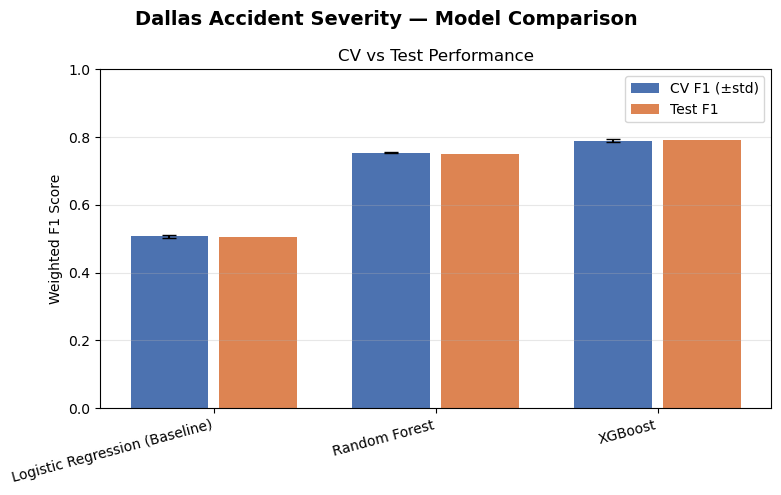

In [13]:
#Model comparison bar chart
fig, ax = plt.subplots(figsize=(8, 5))
fig.suptitle("Dallas Accident Severity — Model Comparison", fontsize=14, fontweight="bold")
names    = list(results.keys())
cv_means = [results[n]["cv_mean"] for n in names]
cv_stds  = [results[n]["cv_std"]  for n in names]
test_f1s = [results[n]["test_f1"] for n in names]
x = np.arange(len(names))
ax.bar(x - 0.2, cv_means, 0.35, yerr=cv_stds, label="CV F1 (±std)", color="#4C72B0", capsize=5)
ax.bar(x + 0.2, test_f1s, 0.35,               label="Test F1",      color="#DD8452")
ax.set_xticks(x)
ax.set_xticklabels(names, rotation=15, ha="right")
ax.set_ylim(0, 1)
ax.set_ylabel("Weighted F1 Score")
ax.set_title("CV vs Test Performance")
ax.legend()
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

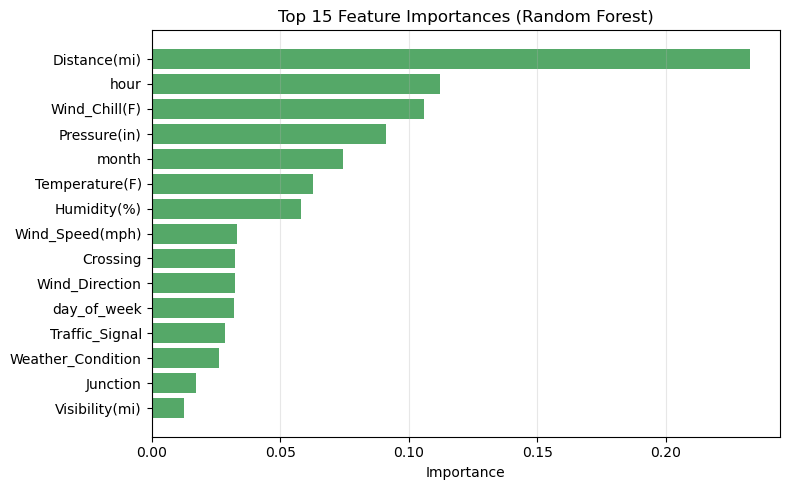

In [14]:
#Feature importance from Random Forest
if "Random Forest" in results:
    fig, ax = plt.subplots(figsize=(8, 5))
    rf_model = results["Random Forest"]["model"]
    feat_imp = pd.Series(rf_model.feature_importances_, index=X_train.columns)
    top15    = feat_imp.sort_values(ascending=False).head(15)
    ax.barh(top15.index[::-1], top15.values[::-1], color="#55A868")
    ax.set_xlabel("Importance")
    ax.set_title("Top 15 Feature Importances (Random Forest)")
    ax.grid(axis="x", alpha=0.3)
    plt.tight_layout()
    plt.show()

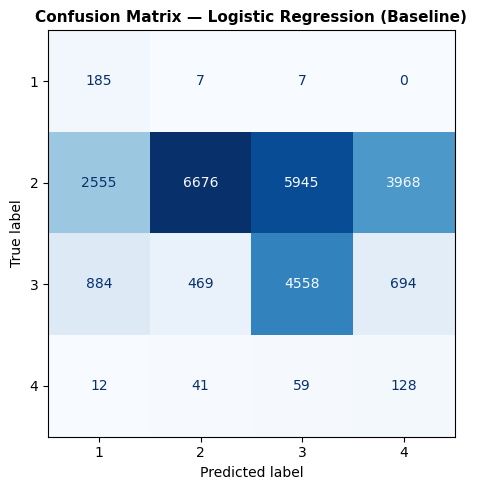

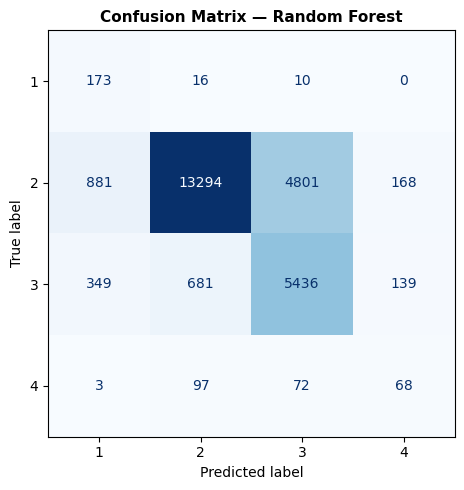

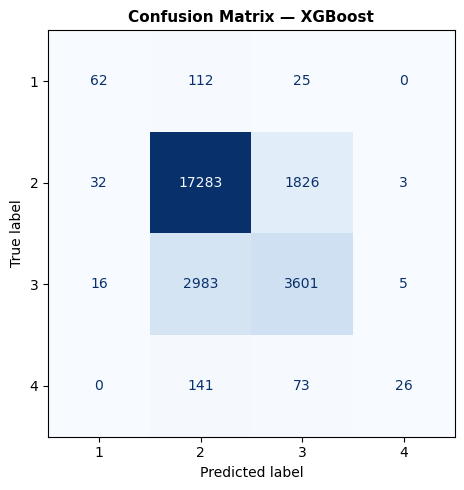

In [15]:
#Confusion matrices — one per model
labels = sorted(y_test.unique())
for name, res in results.items():
    fig, ax = plt.subplots(figsize=(6, 5))
    cm   = confusion_matrix(y_test, res["y_pred"], labels=labels)
    disp = ConfusionMatrixDisplay(cm, display_labels=labels)
    disp.plot(ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(f"Confusion Matrix — {name}", fontsize=11, fontweight="bold")
    plt.tight_layout()
    plt.show()

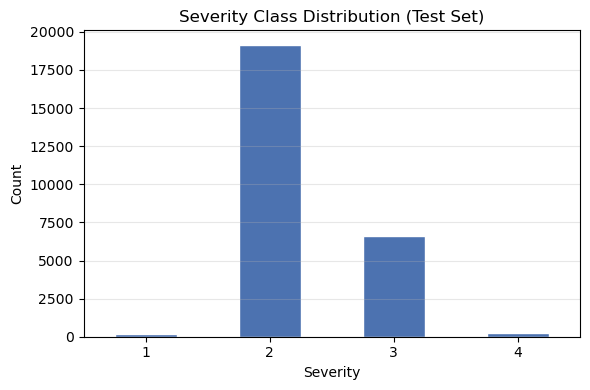

In [16]:
#Severity class distribution
fig, ax = plt.subplots(figsize=(6, 4))
y_test.value_counts().sort_index().plot(kind="bar", ax=ax, color="#4C72B0", edgecolor="white")
ax.set_title("Severity Class Distribution (Test Set)")
ax.set_xlabel("Severity")
ax.set_ylabel("Count")
ax.tick_params(axis="x", rotation=0)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


# Summary Results

In [17]:
# Summary
summary = pd.DataFrame([
    {
        "Model":        name,
        "CV F1 (mean)": f"{r['cv_mean']:.4f}",
        "CV F1 (std)":  f"±{r['cv_std']:.4f}",
        "Test F1":      f"{r['test_f1']:.4f}",
    }
    for name, r in results.items()
])
print(summary.to_string(index=False))
best = max(results, key=lambda n: results[n]["test_f1"])
print(f"\nBest model: {best}  (Test F1 = {results[best]['test_f1']:.4f})")

                         Model CV F1 (mean) CV F1 (std) Test F1
Logistic Regression (Baseline)       0.5066     ±0.0031  0.5057
                 Random Forest       0.7540     ±0.0011  0.7506
                       XGBoost       0.7895     ±0.0034  0.7916

Best model: XGBoost  (Test F1 = 0.7916)


# The best model is XGBoost